- Gather two datasets - successfully extract data using two different data gathering methods and combine the data.
- Assess the data according to quality and tidiness metrics, identifying missing data.
- Clean the data to solve the issues found in the assessing step.
- Update the data store with the cleaned data.
- Produce visualizations on the cleaned data, and answer a brief research question on the dataset.

#### Problem Statement

In 2-4 sentences, explain the problem you want to look at and the datasets you will be wrangling for this project.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

#### Gather at least two datasets using two different data-gathering methods

Options: 

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

In [2]:
# Downloaded data from kaggle via CSV

import kagglehub

# Download latest version
path = kagglehub.dataset_download("tobycrabtree/nfl-scores-and-betting-data")

print("Path to dataset files:", path)

100%|██████████| 250k/250k [00:00<00:00, 4.68MB/s]

Extracting files...
Path to dataset files: C:\Users\jseidl\.cache\kagglehub\datasets\tobycrabtree\nfl-scores-and-betting-data\versions\72


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
scores_bets = pd.read_csv('NFLScore.csv')

In [4]:
scores_bets.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/2/1966,1966,1,False,Miami Dolphins,14.0,23.0,Oakland Raiders,NaN,NaN,NaN,Orange Bowl,False,83.0,6.0,71.0,NaN
1,9/3/1966,1966,1,False,Houston Oilers,45.0,7.0,Denver Broncos,NaN,NaN,NaN,Rice Stadium,False,81.0,7.0,70.0,NaN
2,9/4/1966,1966,1,False,San Diego Chargers,27.0,7.0,Buffalo Bills,NaN,NaN,NaN,Balboa Stadium,False,70.0,7.0,82.0,NaN
3,9/9/1966,1966,2,False,Miami Dolphins,14.0,19.0,New York Jets,NaN,NaN,NaN,Orange Bowl,False,82.0,11.0,78.0,NaN
4,9/10/1966,1966,1,False,Green Bay Packers,24.0,3.0,Baltimore Colts,NaN,NaN,NaN,Lambeau Field,False,64.0,8.0,62.0,NaN


In [ ]:
import requests 
import json
import secrets
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [6]:
url = 'https://api.sportsdata.io/v3/nfl/scores/json/Schedules/%7B2025%7D?key=449cf530965d4cb69fa1e59dd148234c'

In [7]:
response = requests.get(url)
data = response.json()

In [8]:
data

[{'GameKey': '202510126',
  'SeasonType': 1,
  'Season': 2025,
  'Week': 1,
  'Date': '2025-09-04T20:20:00',
  'AwayTeam': 'DAL',
  'HomeTeam': 'PHI',
  'Channel': 'NBC',
  'PointSpread': -6.0,
  'OverUnder': 47.5,
  'StadiumID': 18,
  'Canceled': False,
  'GeoLat': None,
  'GeoLong': None,
  'ForecastTempLow': 65,
  'ForecastTempHigh': 68,
  'ForecastDescription': 'Light Rain',
  'ForecastWindChill': 68,
  'ForecastWindSpeed': 4,
  'AwayTeamMoneyLine': 260,
  'HomeTeamMoneyLine': -328,
  'Day': '2025-09-04T00:00:00',
  'DateTime': '2025-09-04T20:20:00',
  'GlobalGameID': 19039,
  'GlobalAwayTeamID': 9,
  'GlobalHomeTeamID': 26,
  'ScoreID': 19039,
  'Status': 'Final',
  'IsClosed': None,
  'DateTimeUTC': '2025-09-05T00:20:00',
  'StadiumDetails': {'StadiumID': 18,
   'Name': 'Lincoln Financial Field',
   'City': 'Philadelphia',
   'State': 'PA',
   'Country': 'USA',
   'Capacity': 67594,
   'PlayingSurface': 'Grass',
   'GeoLat': 39.900833,
   'GeoLong': -75.167469,
   'Type': 'Outdoo

In [9]:
# Flatten the json structure to break out the nested dictionaries and make it callable to pd.DataFrame
data = pd.json_normalize(data)

In [10]:
# Creating the df and pulling files from json 
schedules = pd.DataFrame(data)[["GameKey", "Week", "Date", "AwayTeam", "HomeTeam", "PointSpread", "OverUnder", "StadiumID", "AwayTeamMoneyLine",
                                 "HomeTeamMoneyLine", "GlobalAwayTeamID", "GlobalHomeTeamID","StadiumDetails.Name", "StadiumDetails.City", "StadiumDetails.Country",
                                   "StadiumDetails.Capacity", "StadiumDetails.PlayingSurface", "StadiumDetails.Type"]]

In [11]:
schedules.head()

,GameKey,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,StadiumID,AwayTeamMoneyLine,HomeTeamMoneyLine,GlobalAwayTeamID,GlobalHomeTeamID,StadiumDetails.Name,StadiumDetails.City,StadiumDetails.Country,StadiumDetails.Capacity,StadiumDetails.PlayingSurface,StadiumDetails.Type
0,202510126,1,2025-09-04T20:20:00,DAL,PHI,-6.0,47.5,18.0,260.0,-328.0,9,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor
1,202510129,1,2025-09-05T20:00:00,KC,LAC,1.7,47.5,87.0,-131.0,111.0,16,29,Arena Corinthians,Sao Paulo,Brazil,47252.0,Grass,Outdoor
2,202510102,1,2025-09-07T13:00:00,TB,ATL,0.3,47.5,45.0,-83.0,-80.0,33,2,Mercedes-Benz Stadium,Atlanta,USA,71000.0,Artificial,RetractableDome
3,202510108,1,2025-09-07T13:00:00,CIN,CLE,2.8,47.5,6.0,-177.0,148.0,7,8,Huntington Bank Field,Cleveland,USA,67431.0,Grass,Outdoor
4,202510114,1,2025-09-07T13:00:00,MIA,IND,-0.7,46.5,9.0,-76.0,-88.0,19,14,Lucas Oil Stadium,Indianapolis,USA,67000.0,Artificial,RetractableDome


In [12]:
scores_bets = scores_bets[scores_bets["schedule_season"] >= 2005]

In [13]:
scores_bets.reset_index(inplace=True)

In [14]:
scores_bets.drop("index", axis=1, inplace=True)

In [15]:
scores_bets.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/8/2005,2005,1,False,New England Patriots,30.0,20.0,Oakland Raiders,NE,-7.5,50,Gillette Stadium,False,71.0,9.0,64.0,NaN
1,9/11/2005,2005,1,False,Baltimore Ravens,7.0,24.0,Indianapolis Colts,IND,-3.0,47,M&T Bank Stadium,False,69.0,4.0,63.0,NaN
2,9/11/2005,2005,1,False,Buffalo Bills,22.0,7.0,Houston Texans,BUF,-4.5,39,Ralph Wilson Stadium,False,64.0,8.0,58.0,NaN
3,9/11/2005,2005,1,False,Carolina Panthers,20.0,23.0,New Orleans Saints,CAR,-6.5,45.5,Bank of America Stadium,False,74.0,12.0,49.0,NaN
4,9/11/2005,2005,1,False,Cleveland Browns,13.0,27.0,Cincinnati Bengals,CIN,-3.5,44.5,FirstEnergy Stadium,False,69.0,6.0,63.0,NaN


In [16]:
scores_bets[["team_home", "team_away"]] = scores_bets[["team_home", "team_away"]].replace({"Oakland Raiders":"Las Vegas Raiders", "San Diego Chargers": "Los Angeles Chargers",
                                                                                               "St. Louis Rams":"Los Angeles Rams", "Washington Redskins":"Washington Commanders", "Washington Football Team":"Washington Commanders"})

In [17]:
scores_bets.query("team_home == 'Oakland Raiders'")

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail


In [18]:
scores_bets.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/8/2005,2005,1,False,New England Patriots,30.0,20.0,Las Vegas Raiders,NE,-7.5,50,Gillette Stadium,False,71.0,9.0,64.0,NaN
1,9/11/2005,2005,1,False,Baltimore Ravens,7.0,24.0,Indianapolis Colts,IND,-3.0,47,M&T Bank Stadium,False,69.0,4.0,63.0,NaN
2,9/11/2005,2005,1,False,Buffalo Bills,22.0,7.0,Houston Texans,BUF,-4.5,39,Ralph Wilson Stadium,False,64.0,8.0,58.0,NaN
3,9/11/2005,2005,1,False,Carolina Panthers,20.0,23.0,New Orleans Saints,CAR,-6.5,45.5,Bank of America Stadium,False,74.0,12.0,49.0,NaN
4,9/11/2005,2005,1,False,Cleveland Browns,13.0,27.0,Cincinnati Bengals,CIN,-3.5,44.5,FirstEnergy Stadium,False,69.0,6.0,63.0,NaN


In [19]:
schedules.head()

,GameKey,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,StadiumID,AwayTeamMoneyLine,HomeTeamMoneyLine,GlobalAwayTeamID,GlobalHomeTeamID,StadiumDetails.Name,StadiumDetails.City,StadiumDetails.Country,StadiumDetails.Capacity,StadiumDetails.PlayingSurface,StadiumDetails.Type
0,202510126,1,2025-09-04T20:20:00,DAL,PHI,-6.0,47.5,18.0,260.0,-328.0,9,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor
1,202510129,1,2025-09-05T20:00:00,KC,LAC,1.7,47.5,87.0,-131.0,111.0,16,29,Arena Corinthians,Sao Paulo,Brazil,47252.0,Grass,Outdoor
2,202510102,1,2025-09-07T13:00:00,TB,ATL,0.3,47.5,45.0,-83.0,-80.0,33,2,Mercedes-Benz Stadium,Atlanta,USA,71000.0,Artificial,RetractableDome
3,202510108,1,2025-09-07T13:00:00,CIN,CLE,2.8,47.5,6.0,-177.0,148.0,7,8,Huntington Bank Field,Cleveland,USA,67431.0,Grass,Outdoor
4,202510114,1,2025-09-07T13:00:00,MIA,IND,-0.7,46.5,9.0,-76.0,-88.0,19,14,Lucas Oil Stadium,Indianapolis,USA,67000.0,Artificial,RetractableDome


In [20]:
teamMap = pd.read_csv('TeamKeys.csv')

In [21]:
teamMap.head()

,HomeTeam,LongName
0,ARI,Arizona Cardinals
1,ATL,Atlanta Falcons
2,BAL,Baltimore Ravens
3,BUF,Buffalo Bills
4,CAR,Carolina Panthers


In [22]:
schedules_with_name = pd.merge(schedules, teamMap, on="HomeTeam")

In [23]:
schedules_with_name.tail()

,GameKey,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,StadiumID,AwayTeamMoneyLine,HomeTeamMoneyLine,GlobalAwayTeamID,GlobalHomeTeamID,StadiumDetails.Name,StadiumDetails.City,StadiumDetails.Country,StadiumDetails.Capacity,StadiumDetails.PlayingSurface,StadiumDetails.Type,LongName
299,202511823,18,2026-01-04T00:00:00,DAL,NYG,NaN,NaN,3.0,NaN,NaN,9,23,MetLife Stadium,East Rutherford,USA,82500.0,Artificial,Outdoor,New York Giants
300,202511826,18,2026-01-04T00:00:00,WAS,PHI,NaN,NaN,18.0,NaN,NaN,35,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor,Philadelphia Eagles
301,202511828,18,2026-01-04T00:00:00,BAL,PIT,NaN,NaN,8.0,NaN,NaN,3,28,Acrisure Stadium,Pittsburgh,USA,68400.0,Grass,Outdoor,Pittsburgh Steelers
302,202511831,18,2026-01-04T00:00:00,SEA,SF,NaN,NaN,37.0,NaN,NaN,30,31,Levi's Stadium,Santa Clara,USA,68500.0,Grass,Outdoor,San Francisco 49ers
303,202511833,18,2026-01-04T00:00:00,CAR,TB,NaN,NaN,24.0,NaN,NaN,5,33,Raymond James Stadium,Tampa Bay,USA,69218.0,Grass,Outdoor,Tampa Bay Buccaneers


In [24]:
scores_bets["LongName"] = scores_bets["team_home"]

In [25]:
scores_bets["schedule_date"] = pd.to_datetime(scores_bets["schedule_date"])

In [26]:
scores_bets.dtypes

schedule_date          datetime64[ns]
schedule_season                 int64
schedule_week                  object
schedule_playoff                 bool
team_home                      object
score_home                    float64
score_away                    float64
team_away                      object
team_favorite_id               object
spread_favorite               float64
over_under_line                object
stadium                        object
stadium_neutral                  bool
weather_temperature           float64
weather_wind_mph              float64
weather_humidity              float64
weather_detail                 object
LongName                       object
dtype: object

In [27]:
scores_bets = scores_bets[scores_bets["schedule_date"].dt.year > 2010]

In [28]:
scores_bets = scores_bets[scores_bets["schedule_date"].dt.year < 2025]

In [29]:
scores_bets.tail()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,LongName
5379,2024-12-29,2024,17,False,New York Giants,45.0,33.0,Indianapolis Colts,IND,-7.5,40.5,Highmark Stadium,False,NaN,NaN,NaN,NaN,New York Giants
5380,2024-12-29,2024,17,False,Philadelphia Eagles,41.0,7.0,Dallas Cowboys,PHI,-7.5,37.5,Lincoln Financial Field,False,NaN,NaN,NaN,NaN,Philadelphia Eagles
5381,2024-12-29,2024,17,False,Tampa Bay Buccaneers,48.0,14.0,Carolina Panthers,TB,-10.0,47.5,Raymond James Stadium,False,NaN,NaN,NaN,NaN,Tampa Bay Buccaneers
5382,2024-12-29,2024,17,False,Washington Commanders,30.0,24.0,Atlanta Falcons,WAS,-3.5,46.5,FedEx Field,False,NaN,NaN,NaN,NaN,Washington Commanders
5383,2024-12-30,2024,17,False,San Francisco 49ers,34.0,40.0,Detroit Lions,DET,-4.0,50,Levi's Stadium,False,NaN,NaN,NaN,NaN,San Francisco 49ers


In [30]:
schedules_with_name.tail()

,GameKey,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,StadiumID,AwayTeamMoneyLine,HomeTeamMoneyLine,GlobalAwayTeamID,GlobalHomeTeamID,StadiumDetails.Name,StadiumDetails.City,StadiumDetails.Country,StadiumDetails.Capacity,StadiumDetails.PlayingSurface,StadiumDetails.Type,LongName
299,202511823,18,2026-01-04T00:00:00,DAL,NYG,NaN,NaN,3.0,NaN,NaN,9,23,MetLife Stadium,East Rutherford,USA,82500.0,Artificial,Outdoor,New York Giants
300,202511826,18,2026-01-04T00:00:00,WAS,PHI,NaN,NaN,18.0,NaN,NaN,35,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor,Philadelphia Eagles
301,202511828,18,2026-01-04T00:00:00,BAL,PIT,NaN,NaN,8.0,NaN,NaN,3,28,Acrisure Stadium,Pittsburgh,USA,68400.0,Grass,Outdoor,Pittsburgh Steelers
302,202511831,18,2026-01-04T00:00:00,SEA,SF,NaN,NaN,37.0,NaN,NaN,30,31,Levi's Stadium,Santa Clara,USA,68500.0,Grass,Outdoor,San Francisco 49ers
303,202511833,18,2026-01-04T00:00:00,CAR,TB,NaN,NaN,24.0,NaN,NaN,5,33,Raymond James Stadium,Tampa Bay,USA,69218.0,Grass,Outdoor,Tampa Bay Buccaneers


In [31]:
schedules_with_name.columns

Index(['GameKey', 'Week', 'Date', 'AwayTeam', 'HomeTeam', 'PointSpread',
       'OverUnder', 'StadiumID', 'AwayTeamMoneyLine', 'HomeTeamMoneyLine',
       'GlobalAwayTeamID', 'GlobalHomeTeamID', 'StadiumDetails.Name',
       'StadiumDetails.City', 'StadiumDetails.Country',
       'StadiumDetails.Capacity', 'StadiumDetails.PlayingSurface',
       'StadiumDetails.Type', 'LongName'],
      dtype='object')

In [32]:
scores_bets.columns

Index(['schedule_date', 'schedule_season', 'schedule_week', 'schedule_playoff',
       'team_home', 'score_home', 'score_away', 'team_away',
       'team_favorite_id', 'spread_favorite', 'over_under_line', 'stadium',
       'stadium_neutral', 'weather_temperature', 'weather_wind_mph',
       'weather_humidity', 'weather_detail', 'LongName'],
      dtype='object')

In [33]:
schedules_with_name.rename(columns= lambda x: x.strip().lower().replace(".","_"))

,gamekey,week,date,awayteam,hometeam,pointspread,overunder,stadiumid,awayteammoneyline,hometeammoneyline,globalawayteamid,globalhometeamid,stadiumdetails_name,stadiumdetails_city,stadiumdetails_country,stadiumdetails_capacity,stadiumdetails_playingsurface,stadiumdetails_type,longname
0,202510126,1,2025-09-04T20:20:00,DAL,PHI,-6.0,47.5,18.0,260.0,-328.0,9,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor,Philadelphia Eagles
1,202510129,1,2025-09-05T20:00:00,KC,LAC,1.7,47.5,87.0,-131.0,111.0,16,29,Arena Corinthians,Sao Paulo,Brazil,47252.0,Grass,Outdoor,Los Angeles Chargers
2,202510102,1,2025-09-07T13:00:00,TB,ATL,0.3,47.5,45.0,-83.0,-80.0,33,2,Mercedes-Benz Stadium,Atlanta,USA,71000.0,Artificial,RetractableDome,Atlanta Falcons
3,202510108,1,2025-09-07T13:00:00,CIN,CLE,2.8,47.5,6.0,-177.0,148.0,7,8,Huntington Bank Field,Cleveland,USA,67431.0,Grass,Outdoor,Cleveland Browns
4,202510114,1,2025-09-07T13:00:00,MIA,IND,-0.7,46.5,9.0,-76.0,-88.0,19,14,Lucas Oil Stadium,Indianapolis,USA,67000.0,Artificial,RetractableDome,Indianapolis Colts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,202511823,18,2026-01-04T00:00:00,DAL,NYG,NaN,NaN,3.0,NaN,NaN,9,23,MetLife Stadium,East Rutherford,USA,82500.0,Artificial,Outdoor,New York Giants
300,202511826,18,2026-01-04T00:00:00,WAS,PHI,NaN,NaN,18.0,NaN,NaN,35,26,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor,Philadelphia Eagles
301,202511828,18,2026-01-04T00:00:00,BAL,PIT,NaN,NaN,8.0,NaN,NaN,3,28,Acrisure Stadium,Pittsburgh,USA,68400.0,Grass,Outdoor,Pittsburgh Steelers
302,202511831,18,2026-01-04T00:00:00,SEA,SF,NaN,NaN,37.0,NaN,NaN,30,31,Levi's Stadium,Santa Clara,USA,68500.0,Grass,Outdoor,San Francisco 49ers


In [34]:
scores_bets.columns

Index(['schedule_date', 'schedule_season', 'schedule_week', 'schedule_playoff',
       'team_home', 'score_home', 'score_away', 'team_away',
       'team_favorite_id', 'spread_favorite', 'over_under_line', 'stadium',
       'stadium_neutral', 'weather_temperature', 'weather_wind_mph',
       'weather_humidity', 'weather_detail', 'LongName'],
      dtype='object')

In [35]:
schedules_with_name.columns

Index(['GameKey', 'Week', 'Date', 'AwayTeam', 'HomeTeam', 'PointSpread',
       'OverUnder', 'StadiumID', 'AwayTeamMoneyLine', 'HomeTeamMoneyLine',
       'GlobalAwayTeamID', 'GlobalHomeTeamID', 'StadiumDetails.Name',
       'StadiumDetails.City', 'StadiumDetails.Country',
       'StadiumDetails.Capacity', 'StadiumDetails.PlayingSurface',
       'StadiumDetails.Type', 'LongName'],
      dtype='object')

In [36]:
scores_bets.rename(columns=({"schedule_date":"Date",
                             "schedule_season":"Year",
                             "schedule_week": "Week",
                             "team_home":"HomeTeam",
                             "score_home": "HomeTeamScore",
                             "score_away":"AwayTeamScore",
                             "team_away": "AwayTeam",
                             "spread_favorite":"PointSpread",
                             "over_under_line": "OverUnder",
                             "stadium": "Stadium"
                             }),inplace=True)

In [37]:
scores_bets.head(1)

,Date,Year,Week,schedule_playoff,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,team_favorite_id,PointSpread,OverUnder,Stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,LongName
1575,2011-01-02,2010,17,False,Atlanta Falcons,31.0,10.0,Carolina Panthers,ATL,-14.5,41.5,Georgia Dome,False,72.0,0.0,NaN,indoor,Atlanta Falcons


In [38]:
scores_bets = scores_bets[scores_bets["schedule_playoff"] == False]

In [39]:
scores_bets.head()

,Date,Year,Week,schedule_playoff,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,team_favorite_id,PointSpread,OverUnder,Stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,LongName
1575,2011-01-02,2010,17,False,Atlanta Falcons,31.0,10.0,Carolina Panthers,ATL,-14.5,41.5,Georgia Dome,False,72.0,0.0,NaN,indoor,Atlanta Falcons
1576,2011-01-02,2010,17,False,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,BAL,-9.5,43,M&T Bank Stadium,False,51.0,7.0,73.0,NaN,Baltimore Ravens
1577,2011-01-02,2010,17,False,Cleveland Browns,9.0,41.0,Pittsburgh Steelers,PIT,-6.5,38,FirstEnergy Stadium,False,25.0,1.0,51.0,NaN,Cleveland Browns
1578,2011-01-02,2010,17,False,Denver Broncos,28.0,33.0,Los Angeles Chargers,LAC,-3.5,47.5,Sports Authority Field at Mile High,False,45.0,4.0,22.0,NaN,Denver Broncos
1579,2011-01-02,2010,17,False,Detroit Lions,20.0,13.0,Minnesota Vikings,DET,-3.5,43.5,Ford Field,False,72.0,0.0,NaN,indoor,Detroit Lions


In [40]:
schedules_with_name["PointSpread"]

0     -6.0
1      1.7
2      0.3
3      2.8
4     -0.7
      ... 
299    NaN
300    NaN
301    NaN
302    NaN
303    NaN
Name: PointSpread, Length: 304, dtype: float64

In [41]:
# Impute point spread favorite by deriving from team money line 

In [42]:
scores_bets.drop(["weather_humidity", "schedule_playoff", "stadium_neutral"], axis=1, inplace=True)

In [43]:
scores_bets.columns

Index(['Date', 'Year', 'Week', 'HomeTeam', 'HomeTeamScore', 'AwayTeamScore',
       'AwayTeam', 'team_favorite_id', 'PointSpread', 'OverUnder', 'Stadium',
       'weather_temperature', 'weather_wind_mph', 'weather_detail',
       'LongName'],
      dtype='object')

In [44]:
schedules_with_name.columns

Index(['GameKey', 'Week', 'Date', 'AwayTeam', 'HomeTeam', 'PointSpread',
       'OverUnder', 'StadiumID', 'AwayTeamMoneyLine', 'HomeTeamMoneyLine',
       'GlobalAwayTeamID', 'GlobalHomeTeamID', 'StadiumDetails.Name',
       'StadiumDetails.City', 'StadiumDetails.Country',
       'StadiumDetails.Capacity', 'StadiumDetails.PlayingSurface',
       'StadiumDetails.Type', 'LongName'],
      dtype='object')

In [45]:
schedules_with_name.drop(["GameKey"], inplace=True, axis=1)

In [46]:
schedules_with_name["Date"] = pd.to_datetime(schedules_with_name["Date"])

In [47]:
schedules_with_name.dtypes

Week                                      int64
Date                             datetime64[ns]
AwayTeam                                 object
HomeTeam                                 object
PointSpread                             float64
OverUnder                               float64
StadiumID                               float64
AwayTeamMoneyLine                       float64
HomeTeamMoneyLine                       float64
GlobalAwayTeamID                          int64
GlobalHomeTeamID                          int64
StadiumDetails.Name                      object
StadiumDetails.City                      object
StadiumDetails.Country                   object
StadiumDetails.Capacity                 float64
StadiumDetails.PlayingSurface            object
StadiumDetails.Type                      object
LongName                                 object
dtype: object

In [48]:
schedules_with_name["Year"] = schedules_with_name["Date"].dt.year

In [49]:
schedules_with_name.columns

Index(['Week', 'Date', 'AwayTeam', 'HomeTeam', 'PointSpread', 'OverUnder',
       'StadiumID', 'AwayTeamMoneyLine', 'HomeTeamMoneyLine',
       'GlobalAwayTeamID', 'GlobalHomeTeamID', 'StadiumDetails.Name',
       'StadiumDetails.City', 'StadiumDetails.Country',
       'StadiumDetails.Capacity', 'StadiumDetails.PlayingSurface',
       'StadiumDetails.Type', 'LongName', 'Year'],
      dtype='object')

In [50]:
scores_bets.columns

Index(['Date', 'Year', 'Week', 'HomeTeam', 'HomeTeamScore', 'AwayTeamScore',
       'AwayTeam', 'team_favorite_id', 'PointSpread', 'OverUnder', 'Stadium',
       'weather_temperature', 'weather_wind_mph', 'weather_detail',
       'LongName'],
      dtype='object')

In [51]:
schedules_with_name.drop(["GlobalAwayTeamID", "GlobalHomeTeamID"], inplace=True, axis=1)

In [52]:
schedules_with_name.head(1)

,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,StadiumID,AwayTeamMoneyLine,HomeTeamMoneyLine,StadiumDetails.Name,StadiumDetails.City,StadiumDetails.Country,StadiumDetails.Capacity,StadiumDetails.PlayingSurface,StadiumDetails.Type,LongName,Year
0,1,2025-09-04 20:20:00,DAL,PHI,-6.0,47.5,18.0,260.0,-328.0,Lincoln Financial Field,Philadelphia,USA,67594.0,Grass,Outdoor,Philadelphia Eagles,2025.0


In [53]:
schedules_with_name.rename({"LongName_x":"HomeTeam", "LongName_y":"AwayTeam"}, inplace=True, axis=1)

In [54]:
schedules_with_name.drop(["HomeTeam_y"], axis=1, inplace=True)

KeyError: "['HomeTeam_y'] not found in axis"

In [55]:
scores_bets.head(1)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,team_favorite_id,PointSpread,OverUnder,Stadium,weather_temperature,weather_wind_mph,weather_detail,LongName
1575,2011-01-02,2010,17,Atlanta Falcons,31.0,10.0,Carolina Panthers,ATL,-14.5,41.5,Georgia Dome,72.0,0.0,indoor,Atlanta Falcons


Schedule Changes:
- Home/Away Team Names?
- Drop Staidum ID
- Drop Stadium Capacity
- StadiumDetails. Name to stadium
- 

Score Changes:
- 

In [60]:
schedules_with_name.columns

Index(['Week', 'Date', 'AwayTeam', 'HomeTeam', 'PointSpread', 'OverUnder',
       'AwayTeamMoneyLine', 'HomeTeamMoneyLine', 'StadiumDetails.Name',
       'StadiumDetails.City', 'StadiumDetails.Country',
       'StadiumDetails.Capacity', 'StadiumDetails.PlayingSurface',
       'StadiumDetails.Type', 'LongName', 'Year', 'HomeTeamScore',
       'AwayTeamScore', 'Favorite', 'Temp', 'WindSpeed'],
      dtype='object')

In [62]:
sorted(scores_bets.columns)

['AwayTeam',
 'AwayTeamScore',
 'Date',
 'HomeTeam',
 'HomeTeamScore',
 'LongName',
 'OverUnder',
 'PointSpread',
 'Stadium',
 'Week',
 'Year',
 'team_favorite_id',
 'weather_detail',
 'weather_temperature',
 'weather_wind_mph']

In [58]:
schedules_with_name.drop(["StadiumID"],inplace=True, axis=1)

In [59]:
schedules_with_name[["HomeTeamScore", "AwayTeamScore", "Favorite", "Temp", "WindSpeed"]] = np.nan

In [63]:
schedules_with_name.to_csv('sched_checkpoint.csv',index=False)

In [64]:
scores_bets.to_csv('score_checkpoint.csv', index=False)

In [1]:
import requests 
import json
import secrets
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [73]:
schedule = pd.read_csv('sched_checkpoint.csv')
scores = pd.read_csv('score_checkpoint.csv')

In [74]:
sorted(schedule.columns)

['AwayTeam',
 'AwayTeamMoneyLine',
 'AwayTeamScore',
 'Date',
 'Favorite',
 'HomeTeam',
 'HomeTeamMoneyLine',
 'HomeTeamScore',
 'LongName',
 'OverUnder',
 'PointSpread',
 'StadiumDetails.Capacity',
 'StadiumDetails.City',
 'StadiumDetails.Country',
 'StadiumDetails.Name',
 'StadiumDetails.PlayingSurface',
 'StadiumDetails.Type',
 'Temp',
 'Week',
 'WindSpeed',
 'Year']

In [75]:
schedule.rename({"StadiumDetails.Capacity":"Capacity",
                 "StadiumDetails.City":"City",
                 "StadiumDetails.Country":"Country",
                 "StadiumDetails.Name":"Stadium", "StadiumDetails.PlayingSurface":"Surface",
                 "StadiumDetails.Type":"Type"},axis=1, inplace=True)

In [76]:
sorted(scores.columns)

['AwayTeam',
 'AwayTeamScore',
 'Date',
 'HomeTeam',
 'HomeTeamScore',
 'LongName',
 'OverUnder',
 'PointSpread',
 'Stadium',
 'Week',
 'Year',
 'team_favorite_id',
 'weather_detail',
 'weather_temperature',
 'weather_wind_mph']

In [77]:
scores[["AwayTeamMoneyLine", "HomeTeamMoneyLine", "Capacity", "Country", "Type"]] = np.nan

In [78]:
scores.rename({"team_favorite_id":"Favorite", "weather_detail":"Weather","weather_temperature":"Temp", "weather_wind_mph":"WindSpeed"},axis=1, inplace=True)

In [79]:
scores[["City", "Surface", "Weather"]] = np.nan 

In [80]:
sorted(scores.columns)

['AwayTeam',
 'AwayTeamMoneyLine',
 'AwayTeamScore',
 'Capacity',
 'City',
 'Country',
 'Date',
 'Favorite',
 'HomeTeam',
 'HomeTeamMoneyLine',
 'HomeTeamScore',
 'LongName',
 'OverUnder',
 'PointSpread',
 'Stadium',
 'Surface',
 'Temp',
 'Type',
 'Weather',
 'Week',
 'WindSpeed',
 'Year']

In [81]:
sorted(schedule.columns)

['AwayTeam',
 'AwayTeamMoneyLine',
 'AwayTeamScore',
 'Capacity',
 'City',
 'Country',
 'Date',
 'Favorite',
 'HomeTeam',
 'HomeTeamMoneyLine',
 'HomeTeamScore',
 'LongName',
 'OverUnder',
 'PointSpread',
 'Stadium',
 'Surface',
 'Temp',
 'Type',
 'Week',
 'WindSpeed',
 'Year']

In [82]:
schedule["Weather"] = np.nan

In [83]:
scores.shape

(3647, 22)

In [84]:
schedule.head(2)

,Week,Date,AwayTeam,HomeTeam,PointSpread,OverUnder,AwayTeamMoneyLine,HomeTeamMoneyLine,Stadium,City,...,Surface,Type,LongName,Year,HomeTeamScore,AwayTeamScore,Favorite,Temp,WindSpeed,Weather
0,1,2025-09-04 20:20:00,DAL,PHI,-6.0,47.5,260.0,-328.0,Lincoln Financial Field,Philadelphia,...,Grass,Outdoor,Philadelphia Eagles,2025.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-09-05 20:00:00,KC,LAC,1.7,47.5,-131.0,111.0,Arena Corinthians,Sao Paulo,...,Grass,Outdoor,Los Angeles Chargers,2025.0,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
scores = pd.merge(scores,
                  schedule[["Stadium","Capacity", "City", "Country", "Type", "Surface"]],
                  on="Stadium", how="left")

In [ ]:
# merged = pd.concat([scores, schedule])

In [48]:
scores.head()

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,Capacity_x,Country_x,Type_x,City_x,Surface_x,Capacity_y,Country_y,Type_y,City_y,Surface_y
0,2011-01-02,2010,17,Atlanta Falcons,31.0,10.0,Carolina Panthers,NaN,-14.5,41.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,2010,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,NaN,-9.5,43.0,...,NaN,NaN,NaN,NaN,NaN,71008.0,USA,Outdoor,Baltimore,Grass
2,2011-01-02,2010,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,NaN,-9.5,43.0,...,NaN,NaN,NaN,NaN,NaN,71008.0,USA,Outdoor,Baltimore,Grass
3,2011-01-02,2010,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,NaN,-9.5,43.0,...,NaN,NaN,NaN,NaN,NaN,71008.0,USA,Outdoor,Baltimore,Grass
4,2011-01-02,2010,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,NaN,-9.5,43.0,...,NaN,NaN,NaN,NaN,NaN,71008.0,USA,Outdoor,Baltimore,Grass


In [66]:
scores.shape

(22085, 28)

In [85]:
merged = pd.concat([scores, schedule])

In [94]:
merged.head(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
0,2011-01-02,2010.0,17,Atlanta Falcons,31.0,10.0,Carolina Panthers,ATL,-14.5,41.5,...,0.0,NaN,Atlanta Falcons,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,2010.0,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,BAL,-9.5,43.0,...,7.0,NaN,Baltimore Ravens,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
merged.tail(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
3949,2026-01-04 00:00:00,2026.0,18,SF,NaN,NaN,SEA,NaN,NaN,NaN,...,NaN,NaN,San Francisco 49ers,NaN,NaN,68500.0,USA,Outdoor,Santa Clara,Grass
3950,2026-01-04 00:00:00,2026.0,18,TB,NaN,NaN,CAR,NaN,NaN,NaN,...,NaN,NaN,Tampa Bay Buccaneers,NaN,NaN,69218.0,USA,Outdoor,Tampa Bay,Grass


In [96]:
merged.shape

(3951, 22)

In [93]:
merged.reset_index(drop=True, inplace=True)

In [97]:
merged.dtypes

Date                  object
Year                 float64
Week                   int64
HomeTeam              object
HomeTeamScore        float64
AwayTeamScore        float64
AwayTeam              object
Favorite              object
PointSpread          float64
OverUnder            float64
Stadium               object
Temp                 float64
WindSpeed            float64
Weather              float64
LongName              object
AwayTeamMoneyLine    float64
HomeTeamMoneyLine    float64
Capacity             float64
Country               object
Type                  object
City                  object
Surface               object
dtype: object

In [102]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3951 entries, 0 to 3950
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               3919 non-null   object 
 1   Year               3919 non-null   float64
 2   Week               3951 non-null   int64  
 3   HomeTeam           3951 non-null   object 
 4   HomeTeamScore      3647 non-null   float64
 5   AwayTeamScore      3647 non-null   float64
 6   AwayTeam           3951 non-null   object 
 7   Favorite           3647 non-null   object 
 8   PointSpread        3768 non-null   float64
 9   OverUnder          3768 non-null   float64
 10  Stadium            3919 non-null   object 
 11  Temp               2634 non-null   float64
 12  WindSpeed          2635 non-null   float64
 13  Weather            0 non-null      float64
 14  LongName           3951 non-null   object 
 15  AwayTeamMoneyLine  121 non-null    float64
 16  HomeTeamMoneyLine  121 n

In [100]:
merged["Date"] = pd.to_datetime(merged["Date"],format="mixed")

In [101]:
merged["Date"] = merged["Date"].dt.strftime("%Y-%m-%d")

In [104]:
cols_to_fill = ["Stadium", "Capacity", "Country", "Type", "City", "Surface"]

for col in cols_to_fill:
    merged[col] = merged.groupby("LongName")[col].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))

C:\Users\jseidl\AppData\Local\Temp\ipykernel_45208\3320181154.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[col] = merged.groupby("LongName")[col].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))
C:\Users\jseidl\AppData\Local\Temp\ipykernel_45208\3320181154.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[col] = merged.groupby("LongName")[col].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))
C:\Users\jseidl\AppData\Local\Temp\ipykernel_45208\3320181154.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[col] = merged.groupby("LongName")[col].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))
C:\Users\jseidl\AppData\Local\Temp\ipykernel_4

In [105]:
merged.head(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
0,2011-01-02,2010.0,17,Atlanta Falcons,31.0,10.0,Carolina Panthers,ATL,-14.5,41.5,...,0.0,NaN,Atlanta Falcons,NaN,NaN,71000.0,USA,RetractableDome,Atlanta,Artificial
1,2011-01-02,2010.0,17,Baltimore Ravens,13.0,7.0,Cincinnati Bengals,BAL,-9.5,43.0,...,7.0,NaN,Baltimore Ravens,NaN,NaN,71008.0,USA,Outdoor,Baltimore,Grass


In [106]:
merged.tail(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
3949,2026-01-04,2026.0,18,SF,NaN,NaN,SEA,NaN,NaN,NaN,...,NaN,NaN,San Francisco 49ers,NaN,NaN,68500.0,USA,Outdoor,Santa Clara,Grass
3950,2026-01-04,2026.0,18,TB,NaN,NaN,CAR,NaN,NaN,NaN,...,NaN,NaN,Tampa Bay Buccaneers,NaN,NaN,69218.0,USA,Outdoor,Tampa Bay,Grass


In [107]:
merged = merged[merged["Year"] >= 2015]

In [108]:
merged.head(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
1040,2015-09-10,2015.0,1,New England Patriots,28.0,21.0,Pittsburgh Steelers,NE,-7.0,51.0,...,9.0,NaN,New England Patriots,NaN,NaN,64628.0,USA,Outdoor,Foxborough,Artificial
1041,2015-09-13,2015.0,1,Arizona Cardinals,31.0,19.0,New Orleans Saints,ARI,-2.5,48.5,...,0.0,NaN,Arizona Cardinals,NaN,NaN,63400.0,USA,RetractableDome,Glendale,Grass


In [109]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2879 entries, 1040 to 3950
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2879 non-null   object 
 1   Year               2879 non-null   float64
 2   Week               2879 non-null   int64  
 3   HomeTeam           2879 non-null   object 
 4   HomeTeamScore      2607 non-null   float64
 5   AwayTeamScore      2607 non-null   float64
 6   AwayTeam           2879 non-null   object 
 7   Favorite           2607 non-null   object 
 8   PointSpread        2728 non-null   float64
 9   OverUnder          2728 non-null   float64
 10  Stadium            2879 non-null   object 
 11  Temp               1594 non-null   float64
 12  WindSpeed          1595 non-null   float64
 13  Weather            0 non-null      float64
 14  LongName           2879 non-null   object 
 15  AwayTeamMoneyLine  121 non-null    float64
 16  HomeTeamMoneyLine  121 non

In [114]:
merged.query("HomeTeamScore.notnull()")

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,...,WindSpeed,Weather,LongName,AwayTeamMoneyLine,HomeTeamMoneyLine,Capacity,Country,Type,City,Surface
1040,2015-09-10,2015.0,1,New England Patriots,28.0,21.0,Pittsburgh Steelers,NE,-7.0,51.0,...,9.0,NaN,New England Patriots,NaN,NaN,64628.0,USA,Outdoor,Foxborough,Artificial
1041,2015-09-13,2015.0,1,Arizona Cardinals,31.0,19.0,New Orleans Saints,ARI,-2.5,48.5,...,0.0,NaN,Arizona Cardinals,NaN,NaN,63400.0,USA,RetractableDome,Glendale,Grass
1042,2015-09-13,2015.0,1,Buffalo Bills,27.0,14.0,Indianapolis Colts,IND,-1.0,44.5,...,7.0,NaN,Buffalo Bills,NaN,NaN,71608.0,USA,Outdoor,Orchard Park,Artificial
1043,2015-09-13,2015.0,1,Chicago Bears,23.0,31.0,Green Bay Packers,GB,-6.5,48.5,...,4.0,NaN,Chicago Bears,NaN,NaN,61500.0,USA,Outdoor,Chicago,Grass
1044,2015-09-13,2015.0,1,Dallas Cowboys,27.0,26.0,New York Giants,DAL,-7.0,52.5,...,0.0,NaN,Dallas Cowboys,NaN,NaN,80000.0,USA,RetractableDome,Arlington,Artificial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3642,2024-12-29,2024.0,17,New York Giants,45.0,33.0,Indianapolis Colts,IND,-7.5,40.5,...,NaN,NaN,New York Giants,NaN,NaN,82500.0,USA,Outdoor,East Rutherford,Artificial
3643,2024-12-29,2024.0,17,Philadelphia Eagles,41.0,7.0,Dallas Cowboys,PHI,-7.5,37.5,...,NaN,NaN,Philadelphia Eagles,NaN,NaN,67594.0,USA,Outdoor,Philadelphia,Grass
3644,2024-12-29,2024.0,17,Tampa Bay Buccaneers,48.0,14.0,Carolina Panthers,TB,-10.0,47.5,...,NaN,NaN,Tampa Bay Buccaneers,NaN,NaN,69218.0,USA,Outdoor,Tampa Bay,Grass
3645,2024-12-29,2024.0,17,Washington Commanders,30.0,24.0,Atlanta Falcons,WAS,-3.5,46.5,...,NaN,NaN,Washington Commanders,NaN,NaN,62000.0,USA,Outdoor,Landover,Grass


In [119]:
merged.drop(columns=["HomeTeamMoneyLine", "AwayTeamMoneyLine"],inplace=True, axis=1)

In [120]:
merged.columns

Index(['Date', 'Year', 'Week', 'HomeTeam', 'HomeTeamScore', 'AwayTeamScore',
       'AwayTeam', 'Favorite', 'PointSpread', 'OverUnder', 'Stadium', 'Temp',
       'WindSpeed', 'Weather', 'LongName', 'Capacity', 'Country', 'Type',
       'City', 'Surface'],
      dtype='object')

In [121]:
merged.head(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,Stadium,Temp,WindSpeed,Weather,LongName,Capacity,Country,Type,City,Surface
1040,2015-09-10,2015.0,1,New England Patriots,28.0,21.0,Pittsburgh Steelers,NE,-7.0,51.0,Gillette Stadium,64.0,9.0,NaN,New England Patriots,64628.0,USA,Outdoor,Foxborough,Artificial
1041,2015-09-13,2015.0,1,Arizona Cardinals,31.0,19.0,New Orleans Saints,ARI,-2.5,48.5,University of Phoenix Stadium,72.0,0.0,NaN,Arizona Cardinals,63400.0,USA,RetractableDome,Glendale,Grass


In [124]:
merged.tail(2)

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,Stadium,Temp,WindSpeed,Weather,LongName,Capacity,Country,Type,City,Surface
3949,2026-01-04,2026.0,18,San Francisco 49ers,NaN,NaN,SEA,NaN,NaN,NaN,Levi's Stadium,NaN,NaN,NaN,San Francisco 49ers,68500.0,USA,Outdoor,Santa Clara,Grass
3950,2026-01-04,2026.0,18,Tampa Bay Buccaneers,NaN,NaN,CAR,NaN,NaN,NaN,Raymond James Stadium,NaN,NaN,NaN,Tampa Bay Buccaneers,69218.0,USA,Outdoor,Tampa Bay,Grass


In [123]:
merged["HomeTeam"] = merged["LongName"]

In [125]:
teams = pd.read_csv('TeamKeys.csv')

In [126]:
teams.head(1)

,HomeTeam,LongName
0,ARI,Arizona Cardinals


In [127]:
# Building name/short name dict
team_map = teams.set_index("HomeTeam")["LongName"].to_dict()

In [128]:
merged["HomeTeam"] = merged["HomeTeam"].replace(team_map)
merged["AwayTeam"] = merged["AwayTeam"].replace(team_map)

In [130]:
merged.head()

,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,Stadium,Temp,WindSpeed,Weather,LongName,Capacity,Country,Type,City,Surface
1040,2015-09-10,2015.0,1,New England Patriots,28.0,21.0,Pittsburgh Steelers,NE,-7.0,51.0,Gillette Stadium,64.0,9.0,NaN,New England Patriots,64628.0,USA,Outdoor,Foxborough,Artificial
1041,2015-09-13,2015.0,1,Arizona Cardinals,31.0,19.0,New Orleans Saints,ARI,-2.5,48.5,University of Phoenix Stadium,72.0,0.0,NaN,Arizona Cardinals,63400.0,USA,RetractableDome,Glendale,Grass
1042,2015-09-13,2015.0,1,Buffalo Bills,27.0,14.0,Indianapolis Colts,IND,-1.0,44.5,Ralph Wilson Stadium,53.0,7.0,NaN,Buffalo Bills,71608.0,USA,Outdoor,Orchard Park,Artificial
1043,2015-09-13,2015.0,1,Chicago Bears,23.0,31.0,Green Bay Packers,GB,-6.5,48.5,Soldier Field,68.0,4.0,NaN,Chicago Bears,61500.0,USA,Outdoor,Chicago,Grass
1044,2015-09-13,2015.0,1,Dallas Cowboys,27.0,26.0,New York Giants,DAL,-7.0,52.5,Cowboys Stadium,72.0,0.0,NaN,Dallas Cowboys,80000.0,USA,RetractableDome,Arlington,Artificial


In [131]:
merged.drop("LongName", axis=1, inplace=True)

In [132]:
merged.dtypes

Date              object
Year             float64
Week               int64
HomeTeam          object
HomeTeamScore    float64
AwayTeamScore    float64
AwayTeam          object
Favorite          object
PointSpread      float64
OverUnder        float64
Stadium           object
Temp             float64
WindSpeed        float64
Weather          float64
Capacity         float64
Country           object
Type              object
City              object
Surface           object
dtype: object

In [133]:
merged.describe()

,Year,Week,HomeTeamScore,AwayTeamScore,PointSpread,OverUnder,Temp,WindSpeed,Weather,Capacity
count,2879.000000,2879.000000,2607.000000,2607.000000,2728.000000,2728.000000,1594.000000,1595.000000,0.0,2879.000000
mean,2020.065995,9.207711,23.599156,21.921366,-5.022067,45.218475,64.779799,3.504075,NaN,69521.675234
std,3.171245,5.122129,10.066779,9.777943,3.509219,4.319445,14.356280,4.535426,NaN,6823.753329
min,2015.000000,1.000000,0.000000,0.000000,-21.500000,28.500000,2.000000,0.000000,NaN,47252.000000
25%,2017.000000,5.000000,17.000000,16.000000,-7.000000,42.500000,58.000000,0.000000,NaN,65515.000000
50%,2020.000000,9.000000,23.000000,21.000000,-4.000000,45.000000,72.000000,1.000000,NaN,68740.000000
75%,2023.000000,14.000000,30.000000,28.000000,-3.000000,48.000000,72.000000,6.000000,NaN,73208.000000
max,2026.000000,18.000000,70.000000,59.000000,5.300000,63.500000,97.000000,33.000000,NaN,86000.000000


In [157]:
np.finfo(np.float16)

finfo(resolution=0.001, min=-6.55040e+04, max=6.55040e+04, dtype=float16)

In [158]:
merged["Year"] = merged["Year"].astype("int16")
merged["Week"] = merged["Week"].astype("int8")
merged["WindSpeed"] = merged["WindSpeed"].astype("float16")
merged["Temp"] = merged["Temp"].astype("float16")
merged["OverUnder"] = merged["OverUnder"].astype("float16")
merged["PointSpread"] = merged["PointSpread"].astype("float16")
merged["AwayTeamScore"] = merged["AwayTeamScore"].astype("float16")
merged["HomeTeamScore"] = merged["HomeTeamScore"].astype("float16")
merged["Capacity"] = merged["Capacity"].astype("int32")



In [166]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2879 entries, 1040 to 3950
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2879 non-null   object 
 1   Year           2879 non-null   int16  
 2   Week           2879 non-null   int8   
 3   HomeTeam       2879 non-null   object 
 4   HomeTeamScore  2607 non-null   float16
 5   AwayTeamScore  2607 non-null   float16
 6   AwayTeam       2879 non-null   object 
 7   Favorite       2607 non-null   object 
 8   PointSpread    2728 non-null   float16
 9   Stadium        2879 non-null   object 
 10  Capacity       2879 non-null   int32  
 11  Country        2879 non-null   object 
 12  Type           2879 non-null   object 
 13  City           2879 non-null   object 
 14  Surface        2879 non-null   object 
dtypes: float16(3), int16(1), int32(1), int8(1), object(9)
memory usage: 261.5+ KB


In [165]:
merged.drop(["Temp", "OverUnder"], axis=1, inplace=True)

In [152]:
merged.drop("Weather", axis=1, inplace=True)

In [161]:
merged["Favorite"].isna().value_counts()

Favorite
False    2607
True      272
Name: count, dtype: int64

In [162]:
merged.drop("WindSpeed", axis=1, inplace=True)

In [164]:
merged.query("Favorite.isna()")

c:\Users\jseidl\DataScience\data\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,OverUnder,Stadium,Temp,Capacity,Country,Type,City,Surface
3647,2025-09-04,2025,1,Philadelphia Eagles,NaN,NaN,Dallas Cowboys,NaN,-6.000000,47.5,Lincoln Financial Field,NaN,67594,USA,Outdoor,Philadelphia,Grass
3648,2025-09-05,2025,1,Los Angeles Chargers,NaN,NaN,Kansas City Chiefs,NaN,1.700195,47.5,Arena Corinthians,NaN,47252,Brazil,Outdoor,Sao Paulo,Grass
3649,2025-09-07,2025,1,Atlanta Falcons,NaN,NaN,Tampa Bay Buccaneers,NaN,0.300049,47.5,Mercedes-Benz Stadium,NaN,71000,USA,RetractableDome,Atlanta,Artificial
3650,2025-09-07,2025,1,Cleveland Browns,NaN,NaN,Cincinnati Bengals,NaN,2.800781,47.5,Huntington Bank Field,NaN,67431,USA,Outdoor,Cleveland,Grass
3651,2025-09-07,2025,1,Indianapolis Colts,NaN,NaN,Miami Dolphins,NaN,-0.700195,46.5,Lucas Oil Stadium,NaN,67000,USA,RetractableDome,Indianapolis,Artificial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3946,2026-01-04,2026,18,New York Giants,NaN,NaN,Dallas Cowboys,NaN,NaN,NaN,MetLife Stadium,NaN,82500,USA,Outdoor,East Rutherford,Artificial
3947,2026-01-04,2026,18,Philadelphia Eagles,NaN,NaN,Washington Commanders,NaN,NaN,NaN,Lincoln Financial Field,NaN,67594,USA,Outdoor,Philadelphia,Grass
3948,2026-01-04,2026,18,Pittsburgh Steelers,NaN,NaN,Baltimore Ravens,NaN,NaN,NaN,Acrisure Stadium,NaN,68400,USA,Outdoor,Pittsburgh,Grass
3949,2026-01-04,2026,18,San Francisco 49ers,NaN,NaN,Seattle Seahawks,NaN,NaN,NaN,Levi's Stadium,NaN,68500,USA,Outdoor,Santa Clara,Grass


In [167]:
merged.describe()

,Year,Week,HomeTeamScore,AwayTeamScore,PointSpread,Capacity
count,2879.000000,2879.000000,2607.00000,2607.000000,2728.000000,2879.000000
mean,2020.065995,9.207711,23.59375,21.921875,-5.023438,69521.675234
std,3.171245,5.122129,10.06250,9.773438,3.509766,6823.753329
min,2015.000000,1.000000,0.00000,0.000000,-21.500000,47252.000000
25%,2017.000000,5.000000,17.00000,16.000000,-7.000000,65515.000000
50%,2020.000000,9.000000,23.00000,21.000000,-4.000000,68740.000000
75%,2023.000000,14.000000,30.00000,28.000000,-3.000000,73208.000000
max,2026.000000,18.000000,70.00000,59.000000,5.300781,86000.000000


In [169]:
merged["PointSpread"].max()

np.float16(5.3)

In [170]:
merged.loc[merged["PointSpread"] == merged["PointSpread"].max()]

c:\Users\jseidl\DataScience\data\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Favorite,PointSpread,Stadium,Capacity,Country,Type,City,Surface
3725,2025-10-05,2025,5,Cincinnati Bengals,NaN,NaN,Detroit Lions,NaN,5.300781,Paycor Stadium,65515,USA,Outdoor,Cincinnati,Artificial


In [171]:
merged.drop(["PointSpread", "Favorite"], axis=1, inplace=True)

In [172]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2879 entries, 1040 to 3950
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2879 non-null   object 
 1   Year           2879 non-null   int16  
 2   Week           2879 non-null   int8   
 3   HomeTeam       2879 non-null   object 
 4   HomeTeamScore  2607 non-null   float16
 5   AwayTeamScore  2607 non-null   float16
 6   AwayTeam       2879 non-null   object 
 7   Stadium        2879 non-null   object 
 8   Capacity       2879 non-null   int32  
 9   Country        2879 non-null   object 
 10  Type           2879 non-null   object 
 11  City           2879 non-null   object 
 12  Surface        2879 non-null   object 
dtypes: float16(2), int16(1), int32(1), int8(1), object(8)
memory usage: 233.4+ KB


In [173]:
merged.to_csv('cleaned_data.csv', index=False)

In [174]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [183]:
lsmodel = merged.copy()

In [184]:
lsmodel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2879 entries, 1040 to 3950
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2879 non-null   object 
 1   Year           2879 non-null   int16  
 2   Week           2879 non-null   int8   
 3   HomeTeam       2879 non-null   object 
 4   HomeTeamScore  2607 non-null   float16
 5   AwayTeamScore  2607 non-null   float16
 6   AwayTeam       2879 non-null   object 
 7   Stadium        2879 non-null   object 
 8   Capacity       2879 non-null   int32  
 9   Country        2879 non-null   object 
 10  Type           2879 non-null   object 
 11  City           2879 non-null   object 
 12  Surface        2879 non-null   object 
 13  intercept      2879 non-null   int64  
dtypes: float16(2), int16(1), int32(1), int64(1), int8(1), object(8)
memory usage: 255.8+ KB


In [185]:
lsmodel.dropna(inplace=True)

In [186]:
lsmodel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2607 entries, 1040 to 3646
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2607 non-null   object 
 1   Year           2607 non-null   int16  
 2   Week           2607 non-null   int8   
 3   HomeTeam       2607 non-null   object 
 4   HomeTeamScore  2607 non-null   float16
 5   AwayTeamScore  2607 non-null   float16
 6   AwayTeam       2607 non-null   object 
 7   Stadium        2607 non-null   object 
 8   Capacity       2607 non-null   int32  
 9   Country        2607 non-null   object 
 10  Type           2607 non-null   object 
 11  City           2607 non-null   object 
 12  Surface        2607 non-null   object 
 13  intercept      2607 non-null   int64  
dtypes: float16(2), int16(1), int32(1), int64(1), int8(1), object(8)
memory usage: 231.7+ KB


In [187]:
lsmodel["Intercept"] = 1

lm = sm.OLS(lsmodel["AwayTeamScore"], lsmodel[["Intercept", "Capacity"]])

In [188]:
results = lm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          AwayTeamScore   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.880
Date:                Tue, 21 Oct 2025   Prob (F-statistic):             0.0490
Time:                        15:29:37   Log-Likelihood:                -9641.0
No. Observations:                2607   AIC:                         1.929e+04
Df Residuals:                    2605   BIC:                         1.930e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7112      1.933     13.298      0.000      21.920      29.503
Capacity   -5.457e-05   2.77e-05     -1.970      0.049      -0.000   -2.48e-07
==============================================================================
Omnibus:                       23.420   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.804
Skew:                           0.204   Prob(JB):                     1.12e-05
Kurtosis:                       2.792   Cond. No.                     7.05e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.05e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [190]:
merged.drop("intercept", axis=1, inplace=True)

In [191]:
lm = sm.OLS(lsmodel["AwayTeamScore"], lsmodel[["Intercept", "Capacity", "Week"]])

In [192]:
results = lm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          AwayTeamScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.006
Date:                Tue, 21 Oct 2025   Prob (F-statistic):             0.0183
Time:                        15:35:28   Log-Likelihood:                -9639.0
No. Observations:                2607   AIC:                         1.928e+04
Df Residuals:                    2604   BIC:                         1.930e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     26.4028      1.962     13.457      0.000      22.555      30.250
Capacity   -5.446e-05   2.77e-05     -1.967      0.049      -0.000   -1.76e-07
Week          -0.0762      0.037     -2.031      0.042      -0.150      -0.003
==============================================================================
Omnibus:                       23.020   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.481
Skew:                           0.203   Prob(JB):                     1.31e-05
Kurtosis:                       2.797   Cond. No.                     7.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [195]:
lsmodel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2607 entries, 1040 to 3646
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2607 non-null   object 
 1   Year           2607 non-null   int16  
 2   Week           2607 non-null   int8   
 3   HomeTeam       2607 non-null   object 
 4   HomeTeamScore  2607 non-null   float16
 5   AwayTeamScore  2607 non-null   float16
 6   AwayTeam       2607 non-null   object 
 7   Stadium        2607 non-null   object 
 8   Capacity       2607 non-null   int32  
 9   Country        2607 non-null   object 
 10  Type           2607 non-null   object 
 11  City           2607 non-null   object 
 12  Surface        2607 non-null   object 
 13  Intercept      2607 non-null   int64  
dtypes: float16(2), int16(1), int32(1), int64(1), int8(1), object(8)
memory usage: 231.7+ KB


In [196]:
logisticR = pd.get_dummies(lsmodel, columns=["Stadium", "City", "Country", "Type", "Surface"], drop_first=True, dtype=int)

In [197]:
logisticR.head()

c:\Users\jseidl\DataScience\data\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\jseidl\DataScience\data\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,Year,Week,HomeTeam,HomeTeamScore,AwayTeamScore,AwayTeam,Capacity,Intercept,Stadium_Acrisure Stadium,...,City_Philadelphia,City_Pittsburgh,City_Santa Clara,City_Sao Paulo,City_Seattle,City_Tampa Bay,Country_USA,Type_Outdoor,Type_RetractableDome,Surface_Grass
1040,2015-09-10,2015,1,New England Patriots,28.0,21.0,Pittsburgh Steelers,64628,1,0,...,0,0,0,0,0,0,1,1,0,0
1041,2015-09-13,2015,1,Arizona Cardinals,31.0,19.0,New Orleans Saints,63400,1,0,...,0,0,0,0,0,0,1,0,1,1
1042,2015-09-13,2015,1,Buffalo Bills,27.0,14.0,Indianapolis Colts,71608,1,0,...,0,0,0,0,0,0,1,1,0,0
1043,2015-09-13,2015,1,Chicago Bears,23.0,31.0,Green Bay Packers,61500,1,0,...,0,0,0,0,0,0,1,1,0,1
1044,2015-09-13,2015,1,Dallas Cowboys,27.0,26.0,New York Giants,80000,1,0,...,0,0,0,0,0,0,1,0,1,0


In [207]:
X = logisticR.drop(columns=["HomeTeam", "AwayTeam", "Date"])
X = sm.add_constant(X)
y = logisticR["AwayTeamScore"]

In [208]:
X.dtypes

Year                      int16
Week                       int8
HomeTeamScore           float16
AwayTeamScore           float16
Capacity                  int32
                         ...   
City_Tampa Bay            int64
Country_USA               int64
Type_Outdoor              int64
Type_RetractableDome      int64
Surface_Grass             int64
Length: 99, dtype: object

In [209]:
lm = sm.OLS(y,X).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          AwayTeamScore   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.551e+25
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:09:02   Log-Likelihood:                 63900.
No. Observations:                2607   AIC:                        -1.276e+05
Df Residuals:                    2522   BIC:                        -1.271e+05
Df Model:                          84                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Year                                         1.919e-15   4.75e-14      0.040      0.968   -9.12e-14    9.51e-14
Week                                         4.684e-16   2.15e-14      0.022      0.983   -4.17e-14    4.27e-14
HomeTeamScore                               -5.378e-17   1.13e-14     -0.005      0.996   -2.23e-14    2.22e-14
AwayTeamScore                                   1.0000   1.15e-14   8.69e+13      0.000       1.000       1.000
Capacity                                     1.681e-17   9.84e-16      0.017      0.986   -1.91e-15    1.95e-15
Intercept                                    4.228e-13   2.12e-11      0.020      0.984   -4.11e-11    4.19e-11
Stadium_Acrisure Stadium                    -1.424e-14   8.47e-13     -0.017      0.987   -1.68e-12    1.65e-12
Stadium_Allegiant Stadium                   -1.443e-15   3.75e-12     -0.000      1.000   -7.36e-12    7.36e-12
Stadium_Allianz Arena                         8.26e-14    7.9e-12      0.010      0.992   -1.54e-11    1.56e-11
Stadium_Arrowhead Stadium                   -7.994e-15   5.08e-12     -0.002      0.999   -9.97e-12    9.95e-12
Stadium_Bank of America Stadium              4.219e-14   9.58e-12      0.004      0.996   -1.87e-11    1.88e-11
Stadium_Caesars Superdome                   -2.109e-15   4.35e-12     -0.000      1.000   -8.53e-12    8.52e-12
Stadium_CenturyLink Field                    4.685e-14   1.78e-12      0.026      0.979   -3.44e-12    3.54e-12
Stadium_Corinthians Arena                    3.295e-14   3.69e-12      0.009      0.993   -7.21e-12    7.28e-12
Stadium_Cowboys Stadium                     -1.499e-15   1.57e-12     -0.001      0.999   -3.09e-12    3.09e-12
Stadium_Dignity Health Sports Park           6.328e-15   3.56e-12      0.002      0.999   -6.97e-12    6.98e-12
Stadium_Edward Jones Dome                    1.815e-14   3.45e-12      0.005      0.996   -6.74e-12    6.78e-12
Stadium_Empower Field at Mile High          -5.373e-14   2.66e-12     -0.020      0.984   -5.28e-12    5.17e-12
Stadium_Estadio Azteca                       1.932e-14   3.84e-12      0.005      0.996   -7.52e-12    7.56e-12
Stadium_EverBank Field                      -7.716e-15   3.07e-12     -0.003      0.998   -6.03e-12    6.01e-12
Stadium_FedEx Field                          1.061e-13   2.99e-12      0.036      0.972   -5.75e-12    5.96e-12
Stadium_FirstEnergy Stadium                  3.003e-14   7.27e-12      0.004      0.997   -1.42e-11    1.43e-11
Stadium_Ford Field                           3.775e-15   6.61e-12      0.001      1.000    -1.3e-11     1.3e-11
Stadium_Frankfurt Stadium                   -1.021e-14   5.49e-12     -0.002      0.999   -1.08e-11    1.08e-11
Stadium_GEHA Field at Arrowhead Stadium     -7.838e-14    5

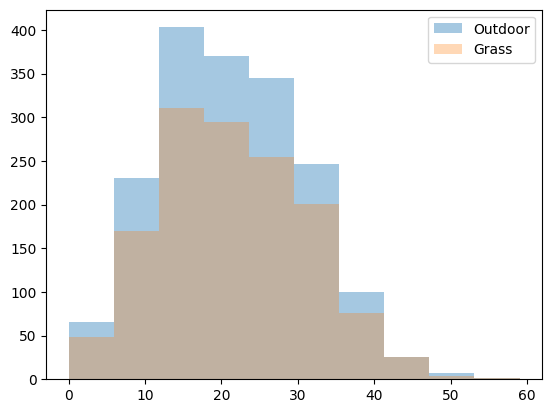

In [222]:
plt.hist(logisticR.query("Type_Outdoor == 1")["AwayTeamScore"], alpha=0.4, label="Outdoor");
plt.hist(logisticR.query("Surface_Grass == 1")["AwayTeamScore"], alpha=0.3, label="Grass");

plt.legend()